# PPE Safety Checker
Detects missing Personal Protective Equipment (PPE) in construction site images.  
Flags workers without helmets, safety vests, or masks and saves annotated alert images.

**Dataset:** Construction Site Safety — 2,801 images, 10 classes  
**Model:** YOLOv8m fine-tuned for 100 epochs  
**Unsafe classes:** `NO-Hardhat` · `NO-Safety Vest` · `NO-Mask`

## 1 — Setup

In [68]:
import os
import cv2
import random
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from pathlib import Path
from ultralytics import YOLO
import torch

BASE      = Path(".").resolve()
DATA_YAML = BASE / "data.yaml"
TRAIN_IMG = BASE / "data" / "train" / "images"
TEST_IMG  = BASE / "data" / "test"  / "images"
SAMPLES   = BASE / "samples"
FLAGGED   = BASE / "flagged"
FLAGGED.mkdir(exist_ok=True)

UNSAFE_CLASSES = {"NO-Hardhat", "NO-Safety Vest", "NO-Mask"}

print(f"PyTorch  : {torch.__version__}")
print(f"GPU      : {torch.cuda.get_device_name(0) if torch.cuda.is_available() else 'CPU only'}")
print(f"Train    : {len(list(TRAIN_IMG.glob('*.jpg')))} images")
print(f"Test     : {len(list(TEST_IMG.glob('*.jpg')))} images")

PyTorch  : 2.11.0+cu128
GPU      : NVIDIA GeForce RTX 5070 Ti
Train    : 2605 images
Test     : 82 images


## 2 — Dataset Overview

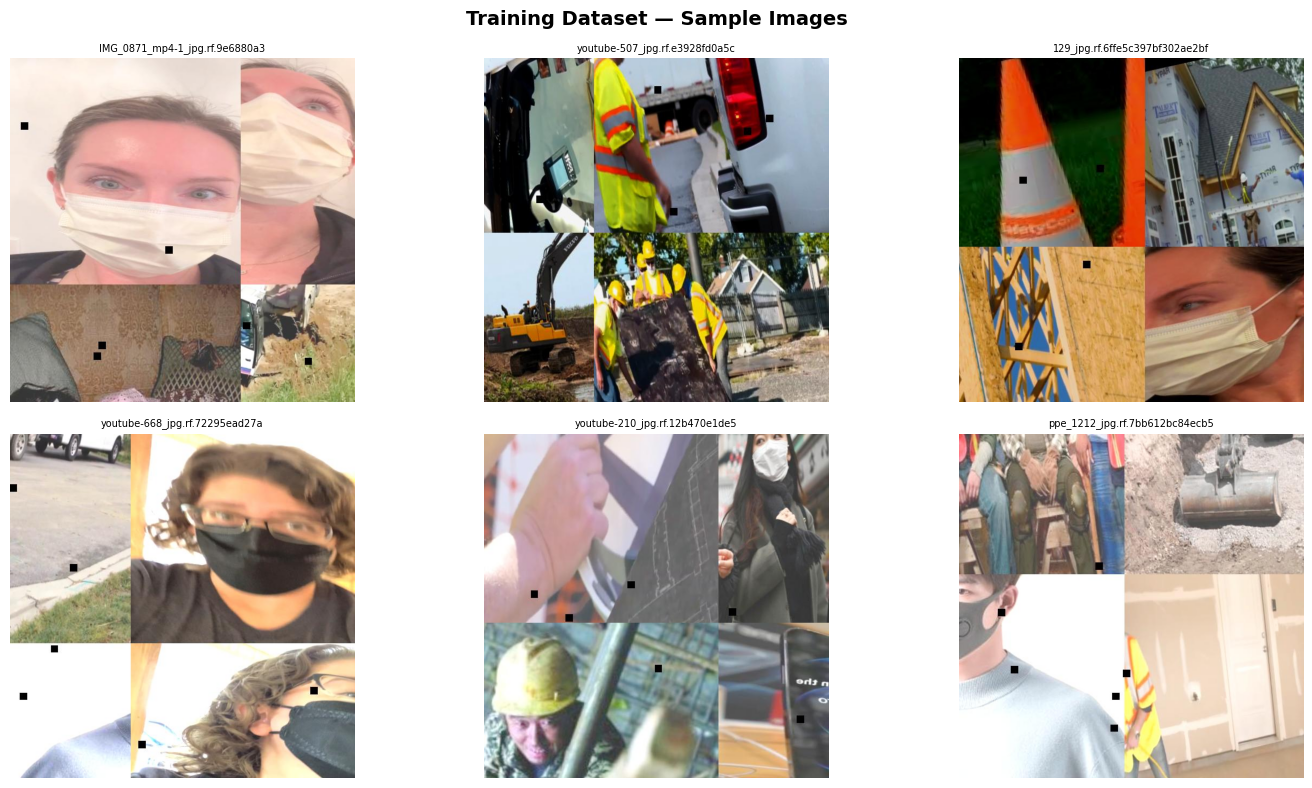

In [69]:
samples = random.sample(list(TRAIN_IMG.glob("*.jpg")), 6)

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
fig.suptitle("Training Dataset — Sample Images", fontsize=14, fontweight="bold")

for ax, img_path in zip(axes.flatten(), samples):
    img = cv2.imread(str(img_path))
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    ax.imshow(img)
    ax.set_title(img_path.name[:30], fontsize=7)
    ax.axis("off")

plt.tight_layout()
plt.show()

## 3 — Model Training
Fine-tuning YOLOv8m on the construction safety dataset.  
The medium variant carries roughly 25M parameters — more capacity than the small variant — which raises recall on partially occluded and background workers, the cases a safety system must not miss.  
YOLO11m was also evaluated (see the Model Comparison below); YOLOv8m was retained for its higher recall, the priority metric for a safety system.  
Training runs on GPU and takes approximately 60–90 minutes.

In [ ]:
model = YOLO("yolov8m.pt")

results = model.train(
    data=str(DATA_YAML),
    epochs=100,
    imgsz=640,
    batch=16,
    name="ppe_model_m",
    project="runs",
    patience=15,
    device=0,
    verbose=True,
)

BEST_MODEL = BASE / "runs" / "detect" / "runs" / "ppe_model_m" / "weights" / "best.pt"
print(f"\nBest model saved to: {BEST_MODEL}")

### Training Results

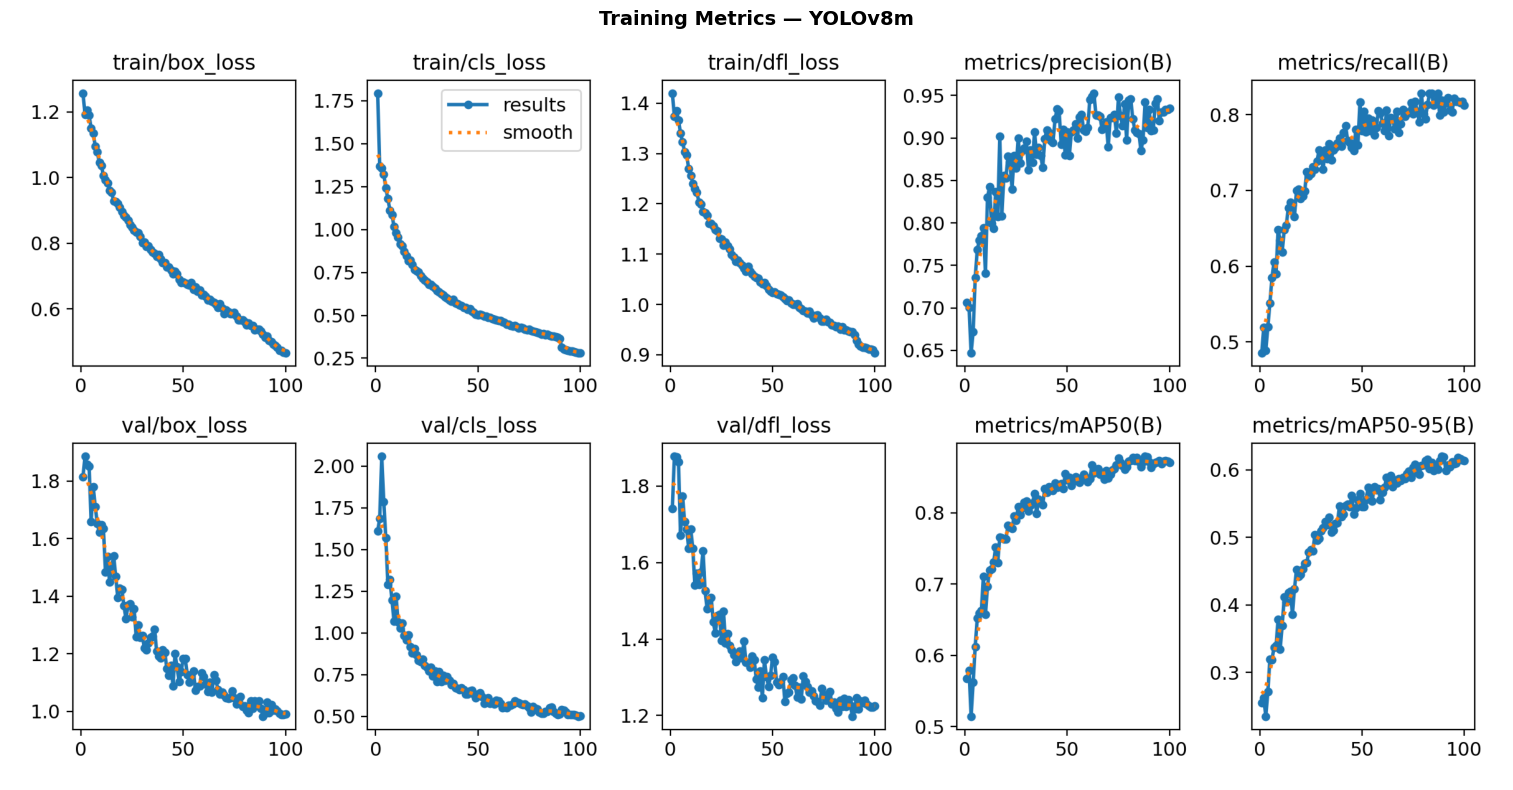

In [70]:
results_img = BASE / "runs" / "detect" / "runs" / "ppe_model_m" / "results.png"

img = cv2.imread(str(results_img))
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

plt.figure(figsize=(16, 8))
plt.imshow(img)
plt.axis("off")
plt.title("Training Metrics — YOLOv8m", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

### Model Comparison
Reads the metrics of every trained model from its `results.csv` and ranks them.  
Each row reports the best-fitness epoch — the same checkpoint saved as `best.pt`.

In [71]:
import pandas as pd

RUNS_DIR = BASE / "runs" / "detect" / "runs"

rows = []
if RUNS_DIR.exists():
    for run in sorted(RUNS_DIR.iterdir()):
        csv = run / "results.csv"
        if not csv.exists():
            continue
        df = pd.read_csv(csv)
        df.columns = df.columns.str.strip()
        fitness = 0.1 * df["metrics/mAP50(B)"] + 0.9 * df["metrics/mAP50-95(B)"]
        best = df.loc[fitness.idxmax()]
        rows.append({
            "model"     : run.name,
            "precision" : round(best["metrics/precision(B)"], 3),
            "recall"    : round(best["metrics/recall(B)"], 3),
            "mAP50"     : round(best["metrics/mAP50(B)"], 3),
            "mAP50-95"  : round(best["metrics/mAP50-95(B)"], 3),
            "best_epoch": int(best["epoch"]) + 1,
        })

if rows:
    comparison = pd.DataFrame(rows).sort_values("mAP50-95", ascending=False).reset_index(drop=True)
    print(comparison.to_string(index=False))
else:
    print("No training runs found in runs/.")
    print("Training output is not version-controlled. Train a model to populate this table,")
    print("or see the saved comparison in the committed notebook outputs.")

       model  precision  recall  mAP50  mAP50-95  best_epoch
     ppe_11m      0.952   0.798  0.868     0.625          90
 ppe_model_m      0.912   0.819  0.878     0.620          90
ppe_model_v2      0.915   0.795  0.854     0.575          89
   ppe_model      0.878   0.695  0.786     0.480          51


### Per-Class Performance
Breaks the chosen model's metrics down by class so we can see exactly which violations it catches reliably and which it misses. Sorted by recall, weakest first.

In [72]:
diag_model  = YOLO(str(BASE / "runs" / "detect" / "runs" / "ppe_model_m" / "weights" / "best.pt"))
val_metrics = diag_model.val(data=str(DATA_YAML), split="val", verbose=False)

names = diag_model.names
idx   = val_metrics.box.ap_class_index

per_class = [{
    "class"    : names[c],
    "precision": round(float(val_metrics.box.p[i]), 3),
    "recall"   : round(float(val_metrics.box.r[i]), 3),
    "mAP50"    : round(float(val_metrics.box.ap50[i]), 3),
    "mAP50-95" : round(float(val_metrics.box.ap[i]), 3),
} for i, c in enumerate(idx)]

per_class_df = pd.DataFrame(per_class).sort_values("recall").reset_index(drop=True)
print("Per-class performance (sorted by recall, weakest first):\n")
print(per_class_df.to_string(index=False))

Ultralytics 8.4.77  Python-3.11.7 torch-2.11.0+cu128 CUDA:0 (NVIDIA GeForce RTX 5070 Ti, 16303MiB)
Model summary (fused): 93 layers, 25,845,550 parameters, 0 gradients, 78.7 GFLOPs
val: Fast image access  (ping: 0.00.0 ms, read: 843.8319.4 MB/s, size: 74.9 KB)
val: Scanning C:\Users\user\Downloads\implementation_GP\ppe-safety-checker\data\valid\labels.cache... 114 images, 10 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 114/114  0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 8/8 6.3it/s 1.3s0.1s
                   all        114        697      0.889      0.836      0.879      0.621
Speed: 1.5ms preprocess, 4.4ms inference, 0.0ms loss, 1.5ms postprocess per image
Results saved to C:\Users\user\Downloads\implementation_GP\ppe-safety-checker\runs\detect\val-9
Per-class performance (sorted by recall, weakest first):

         class  precision  recall  mAP50  mAP50-95
    NO-Hardhat      0.855   0.710  0.827     0.501
       veh

### Experiment — Test-Time Augmentation
TTA runs each image at several scales and flips, then merges the predictions. It often improves recall, but the gain must be measured rather than assumed. The cell below compares violation-class recall with and without TTA on this dataset.

In [73]:
violation_classes = ["NO-Hardhat", "NO-Mask", "NO-Safety Vest"]

def class_recall(augment):
    res = diag_model.val(data=str(DATA_YAML), split="val", augment=augment, workers=0, verbose=False)
    return {diag_model.names[c]: float(res.box.r[i]) for i, c in enumerate(res.box.ap_class_index)}

recall_base = class_recall(augment=False)
recall_tta  = class_recall(augment=True)

tta_rows = [{
    "class"     : c,
    "recall"    : round(recall_base[c], 3),
    "recall_TTA": round(recall_tta[c], 3),
    "delta"     : round(recall_tta[c] - recall_base[c], 3),
} for c in violation_classes]

print("Effect of Test-Time Augmentation on violation-class recall:\n")
print(pd.DataFrame(tta_rows).to_string(index=False))
print(f"\nMean recall, all classes:  base {sum(recall_base.values())/len(recall_base):.3f}"
      f"   TTA {sum(recall_tta.values())/len(recall_tta):.3f}")
print("\nTTA lowers recall on the violation classes here, so it is not used in the final pipeline.")

Ultralytics 8.4.77  Python-3.11.7 torch-2.11.0+cu128 CUDA:0 (NVIDIA GeForce RTX 5070 Ti, 16303MiB)
val: Fast image access  (ping: 0.00.0 ms, read: 734.4335.8 MB/s, size: 58.0 KB)
val: Scanning C:\Users\user\Downloads\implementation_GP\ppe-safety-checker\data\valid\labels.cache... 114 images, 10 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 114/114  0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 8/8 5.7it/s 1.4s0.2s
                   all        114        697      0.889      0.836      0.879      0.621
Speed: 0.2ms preprocess, 4.3ms inference, 0.0ms loss, 0.6ms postprocess per image
Results saved to C:\Users\user\Downloads\implementation_GP\ppe-safety-checker\runs\detect\val-10
Ultralytics 8.4.77  Python-3.11.7 torch-2.11.0+cu128 CUDA:0 (NVIDIA GeForce RTX 5070 Ti, 16303MiB)
val: Fast image access  (ping: 0.00.0 ms, read: 924.9312.0 MB/s, size: 62.6 KB)
val: Scanning C:\Users\user\Downloads\implementation_GP\ppe-safety-check

## 4 — Safety Checker
Runs the trained model on input images. Detections are filtered with **per-class confidence thresholds**: violation classes use a lower threshold (0.25) so borderline cases are still caught, while equipment-present classes use a stricter threshold (0.40). This deliberately favours recall on violations — the priority for a safety system. Any image containing a violation triggers an alert, is annotated with bounding boxes, and saved to the `flagged/` folder.

In [74]:
BEST_MODEL = BASE / "runs" / "detect" / "runs" / "ppe_model_m" / "weights" / "best.pt"
checker    = YOLO(str(BEST_MODEL))

ALERT_COLOR = (0, 0, 255)
SAFE_COLOR  = (0, 200, 0)

# Violations are flagged at a lower confidence than equipment-present detections.
# The per-class diagnosis showed the NO- classes have the weakest recall, and for a
# safety system a missed violation is costlier than a false alarm — so we trade a
# little precision on those classes for higher recall.
VIOLATION_CONF = 0.25
SAFE_CONF      = 0.40

def run_safety_check(image_path: Path) -> dict:
    img    = cv2.imread(str(image_path))
    result = checker(str(image_path), conf=min(VIOLATION_CONF, SAFE_CONF), verbose=False)[0]
    names  = result.names

    detected, alerts = [], []
    for box, cls, conf in zip(result.boxes.xyxy, result.boxes.cls, result.boxes.conf):
        label        = names[int(cls)]
        is_violation = label in UNSAFE_CLASSES
        if float(conf) < (VIOLATION_CONF if is_violation else SAFE_CONF):
            continue

        detected.append(label)
        if is_violation:
            alerts.append(label)

        color = ALERT_COLOR if is_violation else SAFE_COLOR
        x1, y1, x2, y2 = map(int, box)
        cv2.rectangle(img, (x1, y1), (x2, y2), color, 2)
        cv2.putText(img, label, (x1, y1 - 6), cv2.FONT_HERSHEY_SIMPLEX, 0.55, color, 2)

    is_safe      = len(alerts) == 0
    status_text  = "SAFE" if is_safe else f"ALERT: {', '.join(sorted(set(alerts)))}"
    status_color = SAFE_COLOR if is_safe else ALERT_COLOR
    cv2.putText(img, status_text, (10, 30), cv2.FONT_HERSHEY_SIMPLEX, 1.0, status_color, 2)

    if not is_safe:
        out_path = FLAGGED / f"flagged_{image_path.name}"
        cv2.imwrite(str(out_path), img)

    return {
        "file"     : image_path.name,
        "detected" : detected,
        "alerts"   : sorted(set(alerts)),
        "safe"     : is_safe,
        "annotated": img,
    }

### Run on Test Images

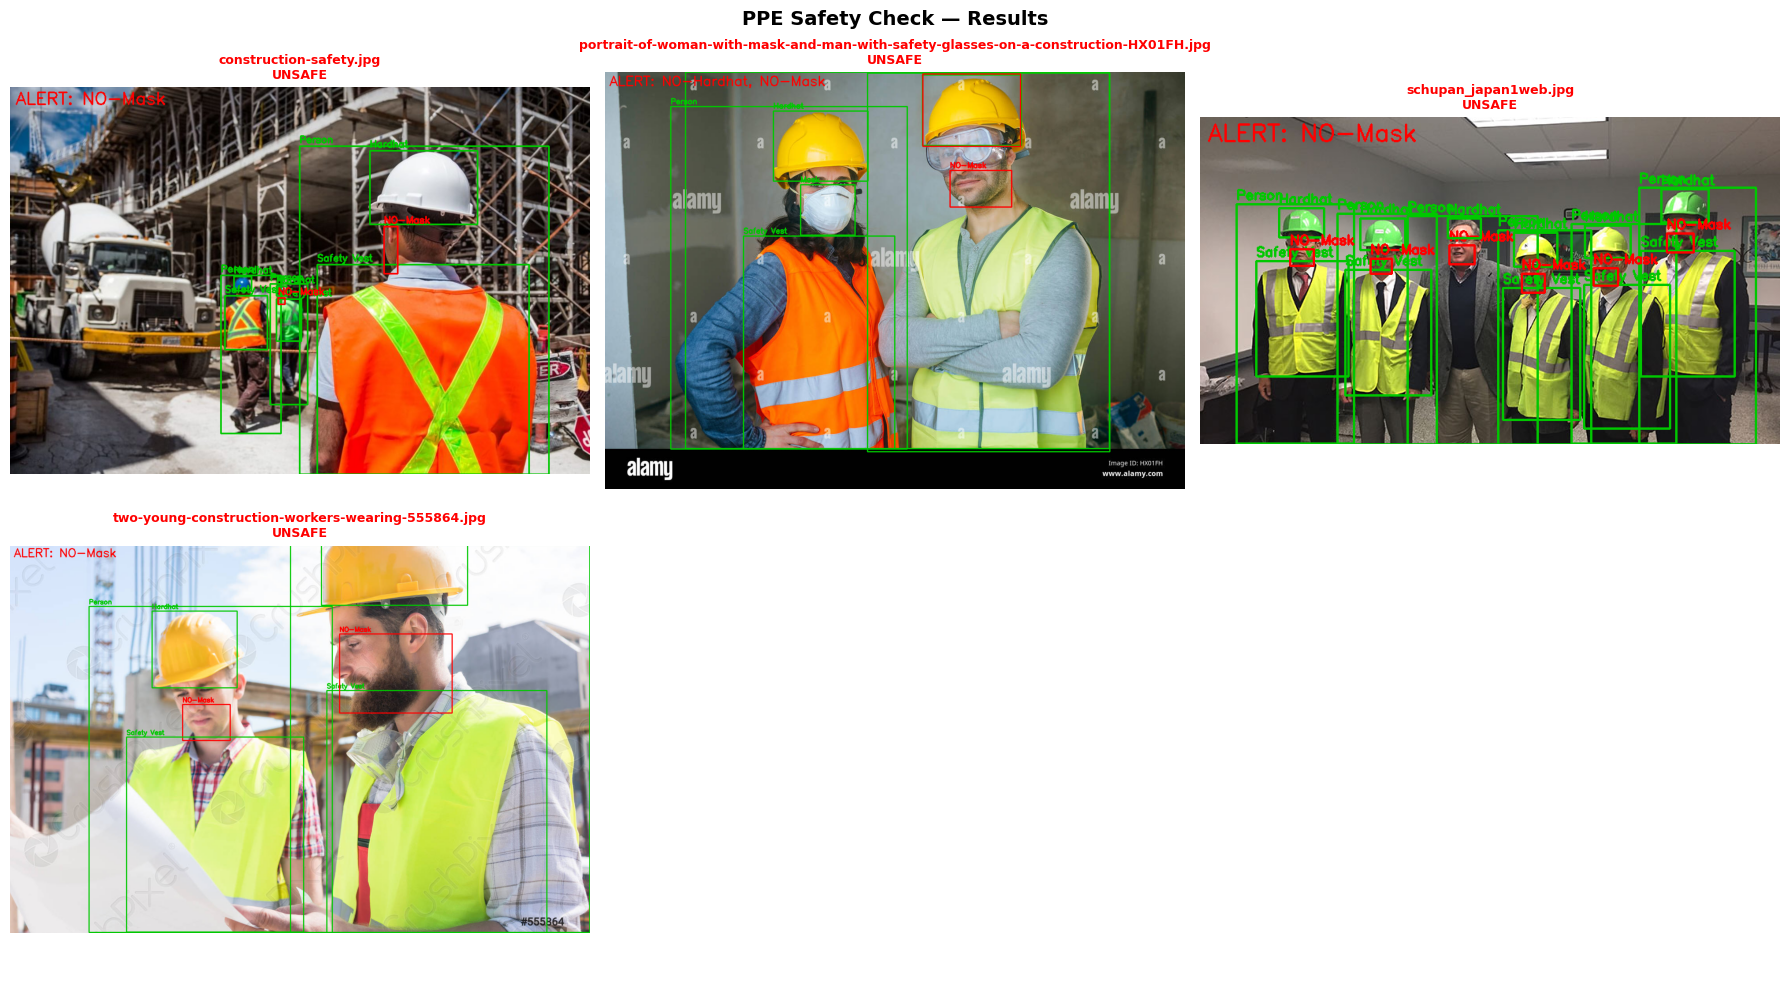

In [75]:
test_images = list(SAMPLES.glob("*.jpg"))
reports     = [run_safety_check(img) for img in test_images]

cols = min(3, len(reports))
rows = (len(reports) + cols - 1) // cols
fig, axes = plt.subplots(rows, cols, figsize=(6 * cols, 5 * rows))
axes = [axes] if len(reports) == 1 else axes.flatten()

for ax, report in zip(axes, reports):
    rgb = cv2.cvtColor(report["annotated"], cv2.COLOR_BGR2RGB)
    ax.imshow(rgb)
    title_color = "red" if not report["safe"] else "green"
    status = "UNSAFE" if not report["safe"] else "SAFE"
    ax.set_title(f"{report['file']}\n{status}", color=title_color, fontsize=9, fontweight="bold")
    ax.axis("off")

for ax in axes[len(reports):]:
    ax.axis("off")

plt.suptitle("PPE Safety Check — Results", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

## 5 — Summary

In [76]:
total    = len(reports)
unsafe   = [r for r in reports if not r["safe"]]
safe     = [r for r in reports if r["safe"]]
flagged  = list(FLAGGED.glob("*.jpg"))

print("=" * 45)
print("         PPE SAFETY CHECK — SUMMARY")
print("=" * 45)
print(f"  Images processed : {total}")
print(f"  Safe             : {len(safe)}")
print(f"  Unsafe (alerts)  : {len(unsafe)}")
print(f"  Flagged images   : {len(flagged)} saved to flagged/")
print("-" * 45)

for r in unsafe:
    violations = ", ".join(r["alerts"])
    print(f"  ⚠  {r['file']}")
    print(f"     Violations: {violations}")

print("=" * 45)

         PPE SAFETY CHECK — SUMMARY
  Images processed : 4
  Safe             : 0
  Unsafe (alerts)  : 4
  Flagged images   : 4 saved to flagged/
---------------------------------------------
  ⚠  construction-safety.jpg
     Violations: NO-Mask
  ⚠  portrait-of-woman-with-mask-and-man-with-safety-glasses-on-a-construction-HX01FH.jpg
     Violations: NO-Hardhat, NO-Mask
  ⚠  schupan_japan1web.jpg
     Violations: NO-Mask
  ⚠  two-young-construction-workers-wearing-555864.jpg
     Violations: NO-Mask


## 6 — Live Video Monitoring
Applies the safety checker frame by frame to a video, the way a real site camera feed would be processed. Each frame is annotated with detections, a live processing-FPS read-out, and the current violation count. Detected violations are written to a timestamped alert log with a short cooldown, so an ongoing violation is recorded once rather than on every frame. The annotated video and the alert log are saved to `outputs/` so they can be replayed and reviewed without rerunning the model.

In [77]:
import time
from datetime import timedelta

OUTPUTS = BASE / "outputs"
OUTPUTS.mkdir(exist_ok=True)

ALERT_COOLDOWN = 3.0  # seconds before the same violation type is logged again

def monitor_video(video_name: str) -> dict:
    cap    = cv2.VideoCapture(str(SAMPLES / video_name))
    fps_in = cap.get(cv2.CAP_PROP_FPS) or 25.0
    w      = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
    h      = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))

    out_path = OUTPUTS / f"monitored_{Path(video_name).stem}.mp4"
    writer   = cv2.VideoWriter(str(out_path), cv2.VideoWriter_fourcc(*"mp4v"), fps_in, (w, h))

    alert_log, last_logged, frame_idx = [], {}, 0

    while True:
        ok, frame = cap.read()
        if not ok:
            break

        t0     = time.time()
        result = checker(frame, conf=min(VIOLATION_CONF, SAFE_CONF), verbose=False)[0]
        names  = result.names

        frame_violations = 0
        for box, cls, conf in zip(result.boxes.xyxy, result.boxes.cls, result.boxes.conf):
            label        = names[int(cls)]
            is_violation = label in UNSAFE_CLASSES
            if float(conf) < (VIOLATION_CONF if is_violation else SAFE_CONF):
                continue

            x1, y1, x2, y2 = map(int, box)
            color = ALERT_COLOR if is_violation else SAFE_COLOR
            cv2.rectangle(frame, (x1, y1), (x2, y2), color, 2)
            cv2.putText(frame, label, (x1, y1 - 6), cv2.FONT_HERSHEY_SIMPLEX, 0.5, color, 2)

            if is_violation:
                frame_violations += 1
                t_video = frame_idx / fps_in
                if t_video - last_logged.get(label, -1e9) >= ALERT_COOLDOWN:
                    last_logged[label] = t_video
                    alert_log.append({"time": str(timedelta(seconds=int(t_video))), "violation": label})

        fps_proc = 1.0 / max(time.time() - t0, 1e-6)
        cv2.putText(frame, f"FPS {fps_proc:4.1f}", (10, 30),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.8, (255, 255, 255), 2)
        cv2.putText(frame, f"Violations: {frame_violations}", (10, 62),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.8, ALERT_COLOR if frame_violations else SAFE_COLOR, 2)

        writer.write(frame)
        frame_idx += 1

    cap.release()
    writer.release()
    return {"output": out_path, "log": alert_log, "frames": frame_idx, "fps": fps_in}


VIDEO  = "hardhat.mp4"
report = monitor_video(VIDEO)

log_df  = pd.DataFrame(report["log"])
log_csv = OUTPUTS / f"alerts_{Path(VIDEO).stem}.csv"
log_df.to_csv(log_csv, index=False)

print(f"Processed {report['frames']} frames from {VIDEO} ({report['fps']:.0f} fps source)")
print(f"Annotated video : {report['output']}")
print(f"Alert log       : {log_csv}  ({len(log_df)} alerts logged)\n")
print(log_df.to_string(index=False) if len(log_df) else "No violations logged.")

Processed 1826 frames from hardhat.mp4 (30 fps source)
Annotated video : C:\Users\user\Downloads\implementation_GP\ppe-safety-checker\outputs\monitored_hardhat.mp4
Alert log       : C:\Users\user\Downloads\implementation_GP\ppe-safety-checker\outputs\alerts_hardhat.csv  (32 alerts logged)

   time      violation
0:00:03        NO-Mask
0:00:03 NO-Safety Vest
0:00:06        NO-Mask
0:00:06     NO-Hardhat
0:00:06 NO-Safety Vest
0:00:09        NO-Mask
0:00:09 NO-Safety Vest
0:00:10     NO-Hardhat
0:00:12        NO-Mask
0:00:12 NO-Safety Vest
0:00:15 NO-Safety Vest
0:00:15        NO-Mask
0:00:18 NO-Safety Vest
0:00:18        NO-Mask
0:00:22 NO-Safety Vest
0:00:27 NO-Safety Vest
0:00:27        NO-Mask
0:00:31 NO-Safety Vest
0:00:33     NO-Hardhat
0:00:34 NO-Safety Vest
0:00:35        NO-Mask
0:00:39 NO-Safety Vest
0:00:42        NO-Mask
0:00:42 NO-Safety Vest
0:00:45 NO-Safety Vest
0:00:46        NO-Mask
0:00:48 NO-Safety Vest
0:00:49        NO-Mask
0:00:51 NO-Safety Vest
0:00:52        NO-M